In [19]:
from datetime import datetime

etherpad_url = "http://localhost:9001/"
notebook7_url = "http://localhost:8888/tree?token=f9dd43d3ea2b173dc795325a179658fd2d1cc3ced7675605"
test_pad_title = f"NBSearch Integration Test {datetime.now().strftime('%Y%m%d_%H%M%S')}"
hashtag1 = "#Notebookの検索"
hashtag2 = "#NBSearchの使い方_-_Notebookの検索"
default_result_path = None
close_on_fail = False
transition_timeout = 10000

In [20]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpz0ss9yxq'

# ep_weave E2E Test - NBSearch Integration

- Test data to prepare: nbsearch service must be running with test notebooks indexed

In [21]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251104-063706',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpbj_gc6gx')

## Establish Jupyter session by accessing notebook7_url

Start epoch: 1762205827.088672 seconds


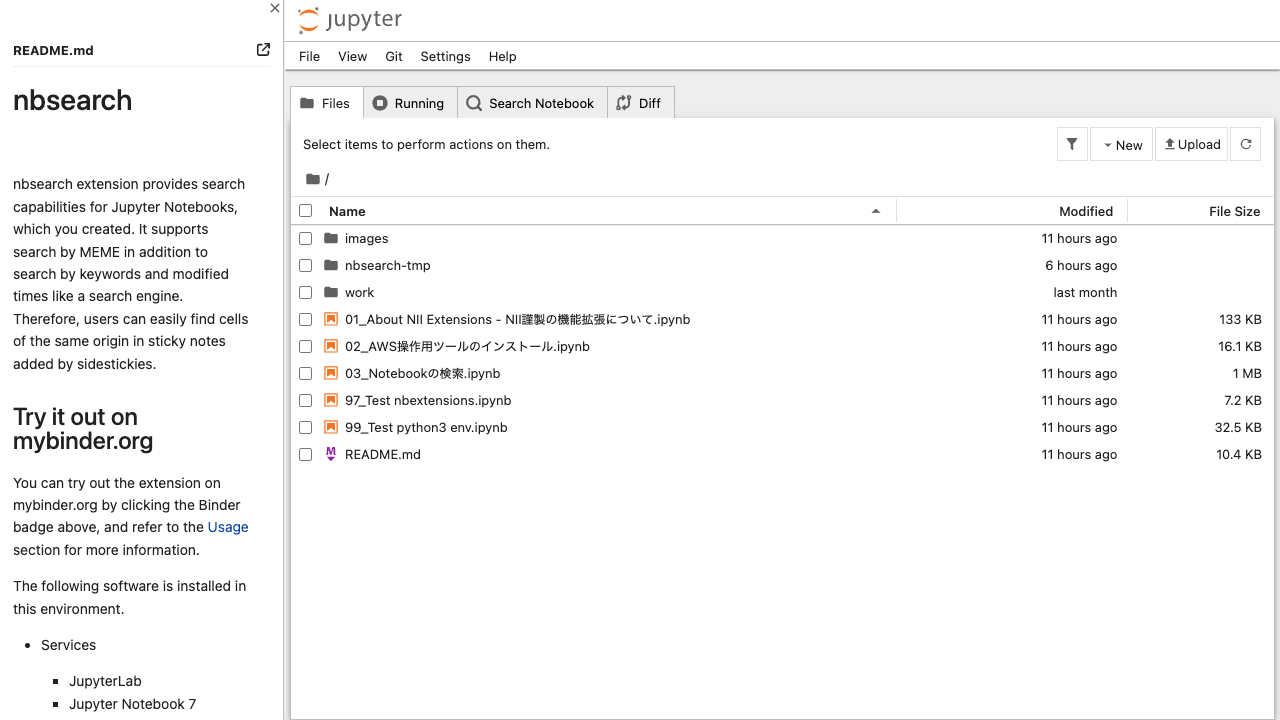

In [22]:
async def _step(page):
    # Access notebook7_url with token to establish session cookie
    await page.goto(notebook7_url)

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('//*[@data-icon="nbsearch::notebooksearch"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## Open etherpad_url and check if the search box is editable

Start epoch: 1762205828.614207 seconds


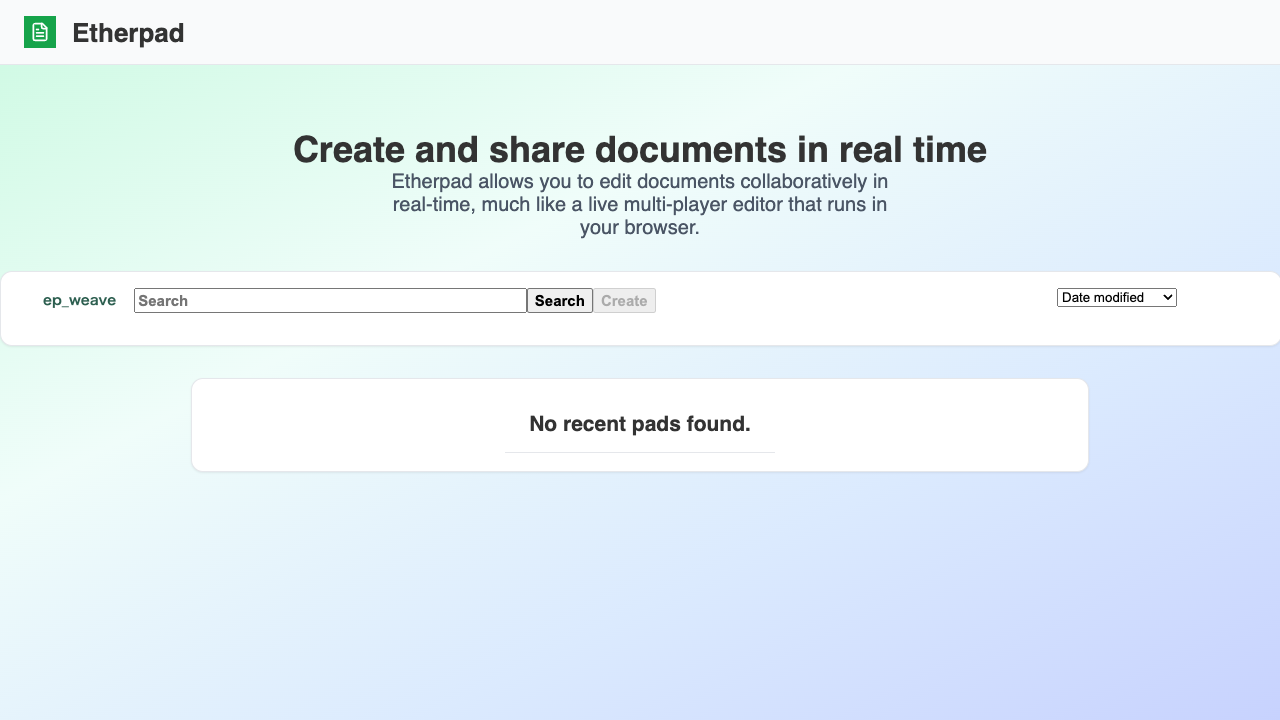

In [23]:
index_page = None

async def _step(page):
    await page.goto(etherpad_url)
    await expect(page.locator(".hashview-search-box")).to_be_editable()

    global index_page
    index_page = page

await run_pw(_step)

## Create a new test pad

Start epoch: 1762205828.855482 seconds


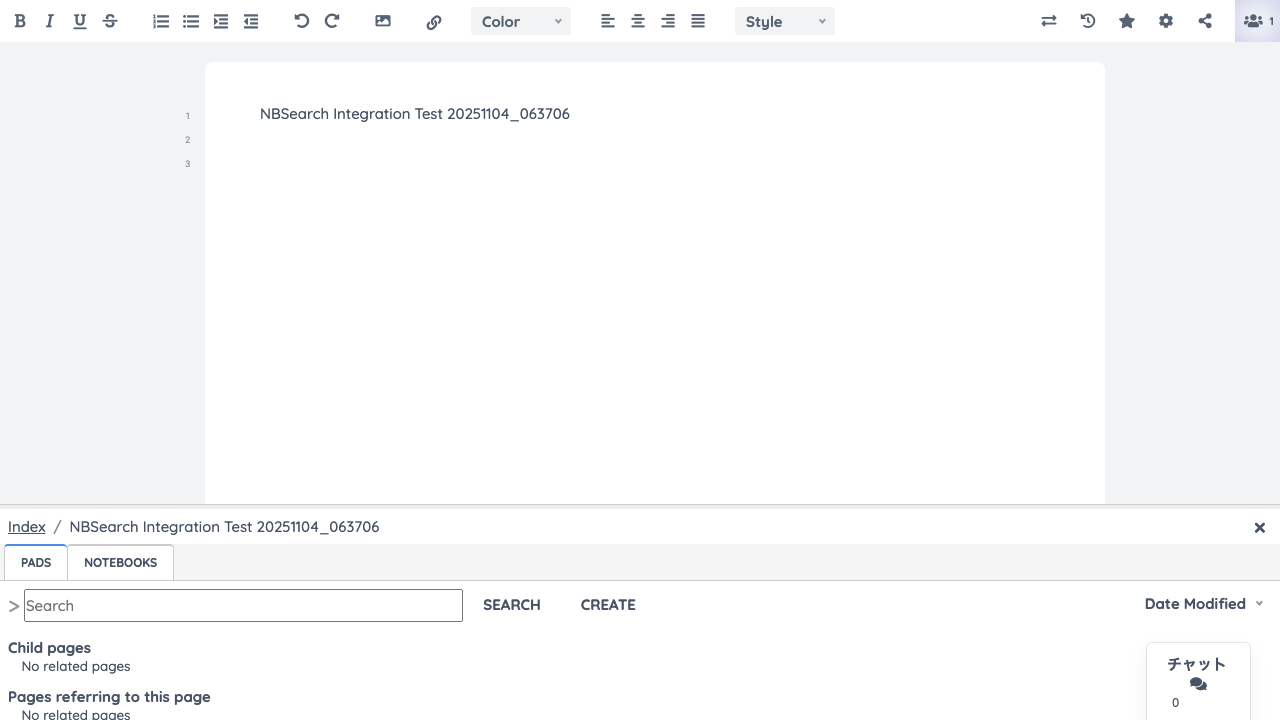

In [24]:
import re

pad_page = None

async def _step(page):
    await page.locator(".hashview-search-box").fill(test_pad_title)
    await expect(page.locator('//button[text()="Create"]')).to_be_enabled()

    popup_future = page.wait_for_event('popup')
    await page.locator('//button[text()="Create"]').click()
    popup = await popup_future
    await expect(popup).to_have_title(re.compile(f"^{test_pad_title}"))
    await expect(popup.locator('//iframe[@name="ace_outer"]')).to_be_visible(timeout=transition_timeout)

    global pad_page
    pad_page = popup
    return popup

await run_pw(_step)

## Add first hashtag for notebook search

Start epoch: 1762205830.0881448 seconds


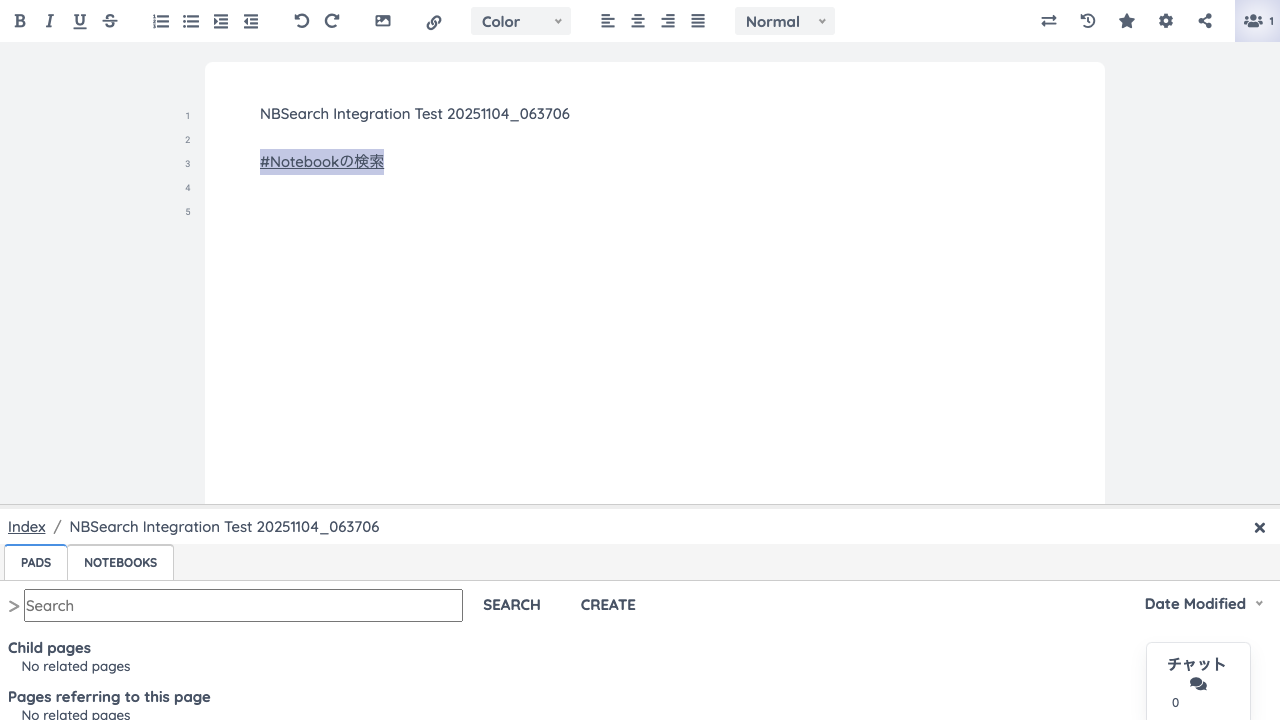

In [25]:
import asyncio

async def extract_ace_inner_docbody(page):
    iframe_locator = page.frame_locator('iframe[name="ace_outer"]').frame_locator('iframe[name="ace_inner"]')
    await expect(iframe_locator.locator('#innerdocbody')).to_be_visible(timeout=transition_timeout)
    return iframe_locator.locator('#innerdocbody')

async def _step(page):
    inner_docbody = await extract_ace_inner_docbody(page)
    await expect(inner_docbody).to_be_editable(timeout=transition_timeout)
    await inner_docbody.focus()
    await inner_docbody.press('End')
    for _ in range(2):
        await inner_docbody.press('Enter')
    await inner_docbody.type(hashtag1, delay=100)
    await expect(inner_docbody).to_contain_text(hashtag1, timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')
    await asyncio.sleep(1)  # wait for the flush to the server

await run_pw(_step)

## Verify notebook search results appear for first hashtag

Start epoch: 1762205832.468788 seconds


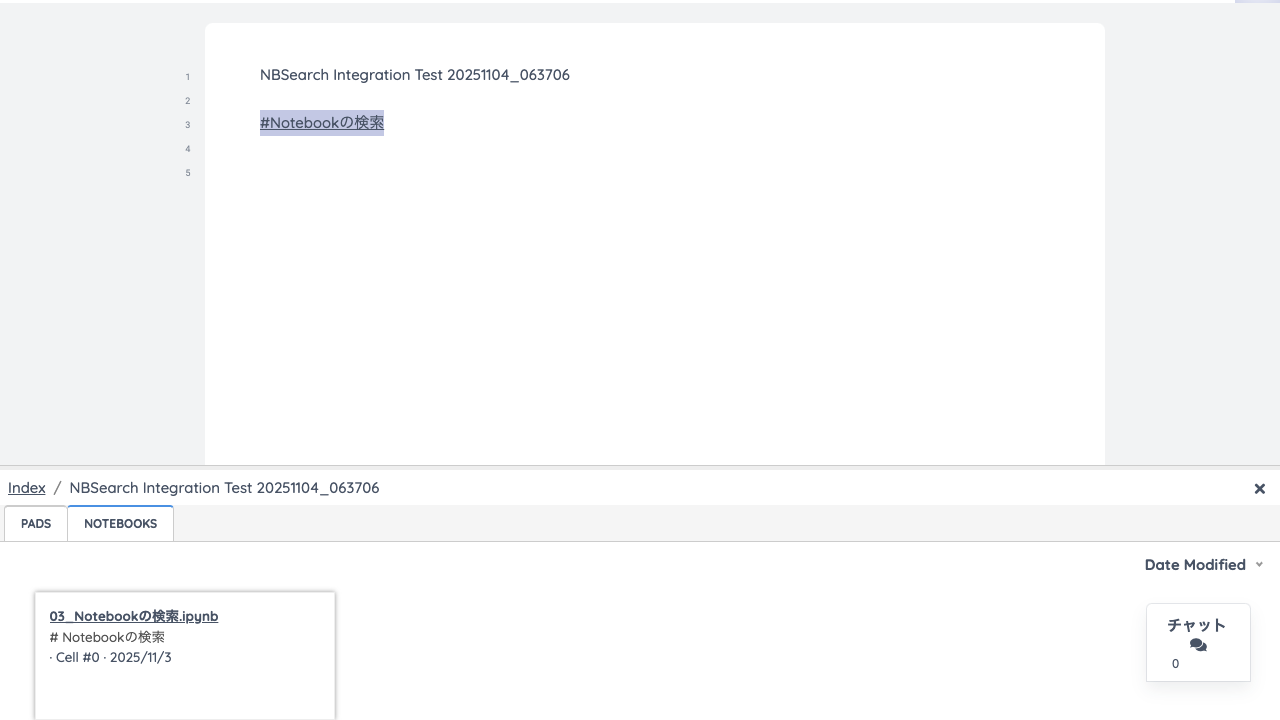

In [26]:
async def _step(page):
    # Click Notebooks tab to view notebook search results
    notebooks_tab = page.locator('.hashview-tab-button[data-tab="notebooks"]')
    await expect(notebooks_tab).to_be_visible(timeout=transition_timeout)
    await notebooks_tab.click()
    
    # Wait for the Notebooks tab content to be active
    notebooks_content = page.locator('.hashview-tab-content[data-tab="notebooks"].hashview-tab-active')
    await expect(notebooks_content).to_be_visible(timeout=transition_timeout)
    
    # Find the section heading for this hashtag
    section_heading_text = f"Notebooks with '{hashtag1}' in headings"
    section_heading = notebooks_content.locator('.hash-text', has_text=section_heading_text)
    await expect(section_heading).to_be_visible(timeout=transition_timeout)
    
    # Find notebook items in the next .hash-container sibling
    # Expect exactly 1 result for the heading "Notebookの検索"
    notebook_items = notebooks_content.locator(f'.hash-text:has-text("{section_heading_text}") + .hash-container .hash-link.notebook-item')
    await expect(notebook_items).to_have_count(1, timeout=transition_timeout)
    await notebook_items.scroll_into_view_if_needed()

await run_pw(_step)

## Click first notebook link to open nbsearch search page

Start epoch: 1762205832.680532 seconds


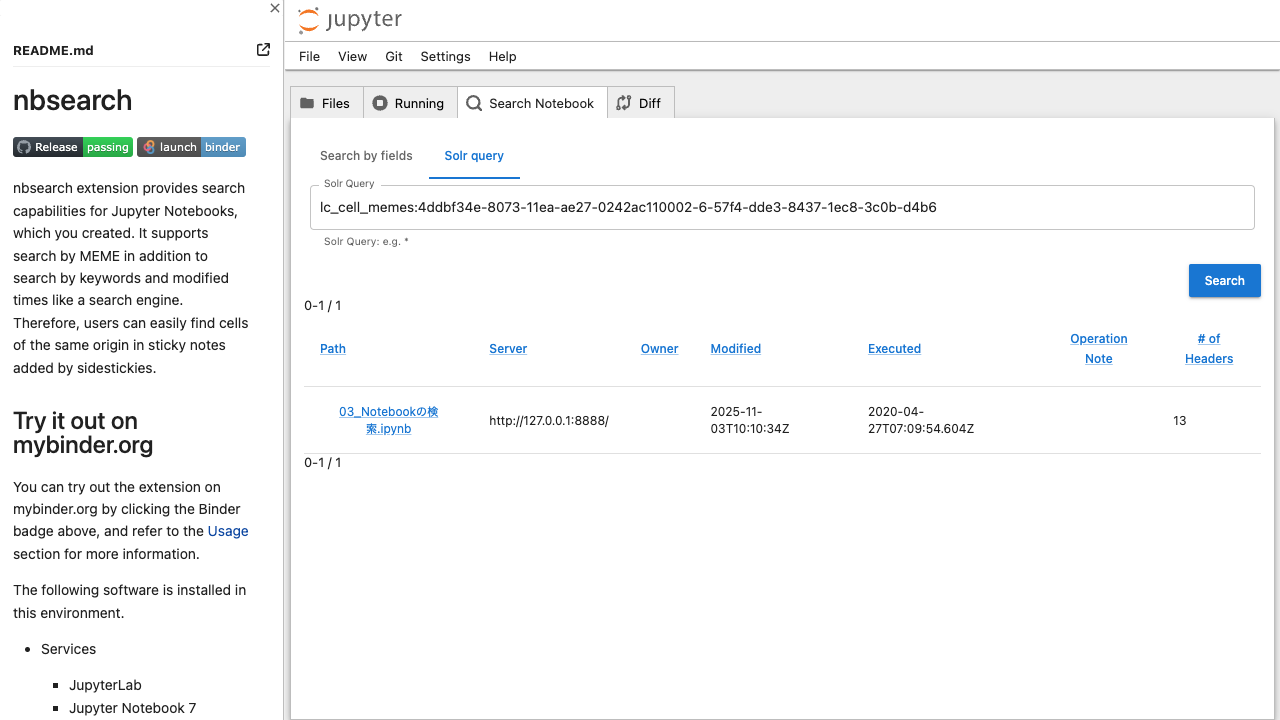

In [27]:
notebook_popup = None

async def _step(page):
    # Ensure we're in the Notebooks tab
    notebooks_content = page.locator('.hashview-tab-content[data-tab="notebooks"].hashview-tab-active')
    await expect(notebooks_content).to_be_visible(timeout=transition_timeout)
    
    section_heading_text = f"Notebooks with '{hashtag1}' in headings"
    # There is exactly 1 notebook link for this heading
    notebook_link = notebooks_content.locator(
        f'.hash-text:has-text("{section_heading_text}") + .hash-container .hash-link.notebook-item .hash-title.notebook-title a'
    )
    
    await expect(notebook_link).to_be_visible(timeout=transition_timeout)
    
    # Click and wait for nbsearch search page to open
    popup_future = page.wait_for_event('popup')
    await notebook_link.click()
    popup = await popup_future
    await popup.wait_for_load_state('networkidle')
    
    # Verify nbsearch search interface is visible
    await expect(popup.locator('.nbsearch-search-root')).to_be_visible(timeout=transition_timeout)
    
    global notebook_popup
    notebook_popup = popup
    return popup

await run_pw(_step)

## Verify search query and results in nbsearch

Start epoch: 1762205835.221035 seconds


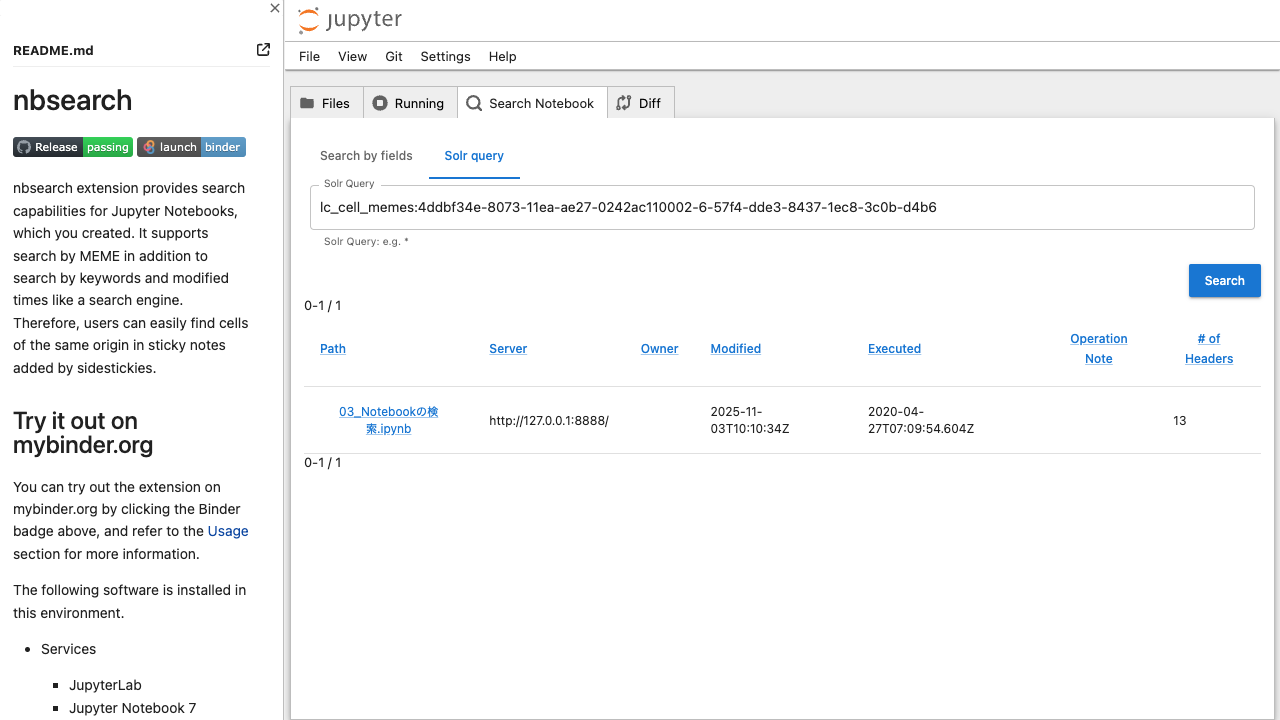

In [28]:
async def _step(page):
    # Verify search results contain the expected heading text
    results_table = page.locator('.MuiTableBody-root')
    await expect(results_table).to_have_count(1, timeout=transition_timeout)
    await expect(results_table).to_contain_text('Notebookの検索', timeout=transition_timeout)

await run_pw(_step)

## Add second hashtag with underscore (test underscore to space conversion)

Start epoch: 1762205835.327629 seconds


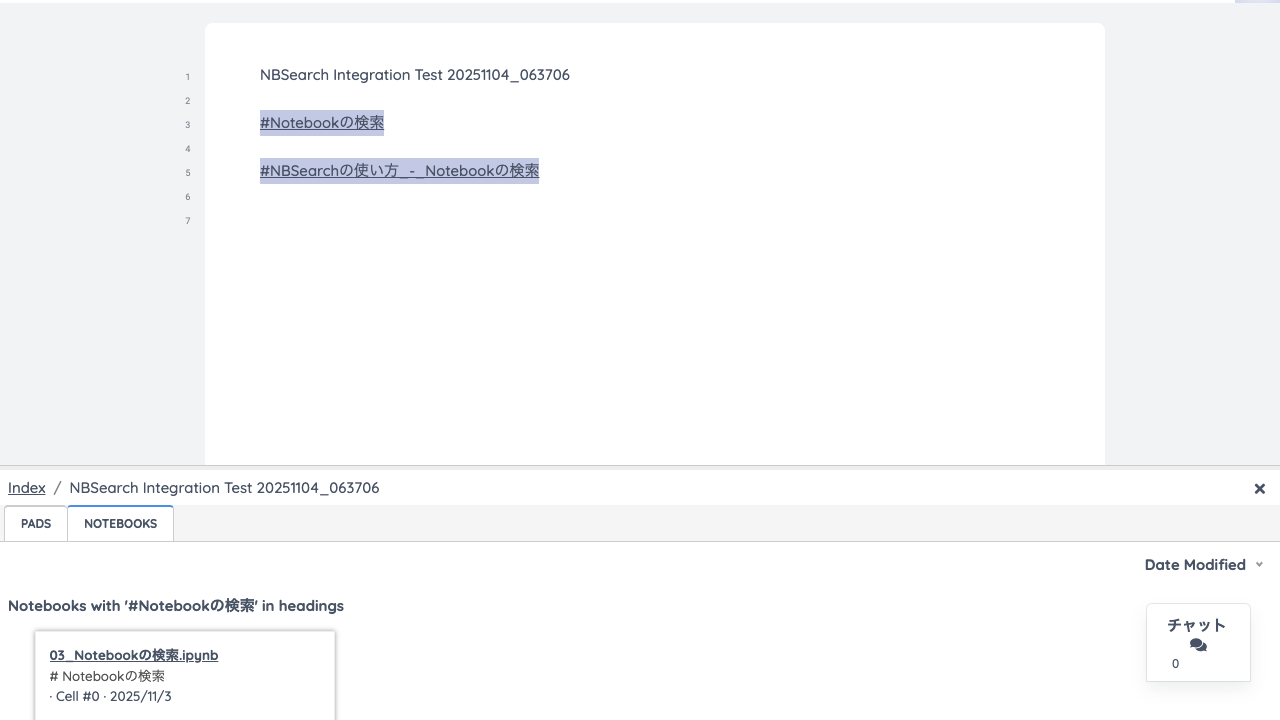

In [29]:
async def _step(page):
    inner_docbody = await extract_ace_inner_docbody(page)
    await inner_docbody.focus()
    await inner_docbody.press('End')
    for _ in range(2):
        await inner_docbody.press('Enter')
    await inner_docbody.type(hashtag2, delay=100)
    await expect(inner_docbody).to_contain_text(hashtag2, timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')
    await asyncio.sleep(1)  # wait for the flush to the server

await close_latest_page()
await run_pw(_step)

## Verify notebook search results appear for second hashtag (with underscore)

Start epoch: 1762205839.23964 seconds


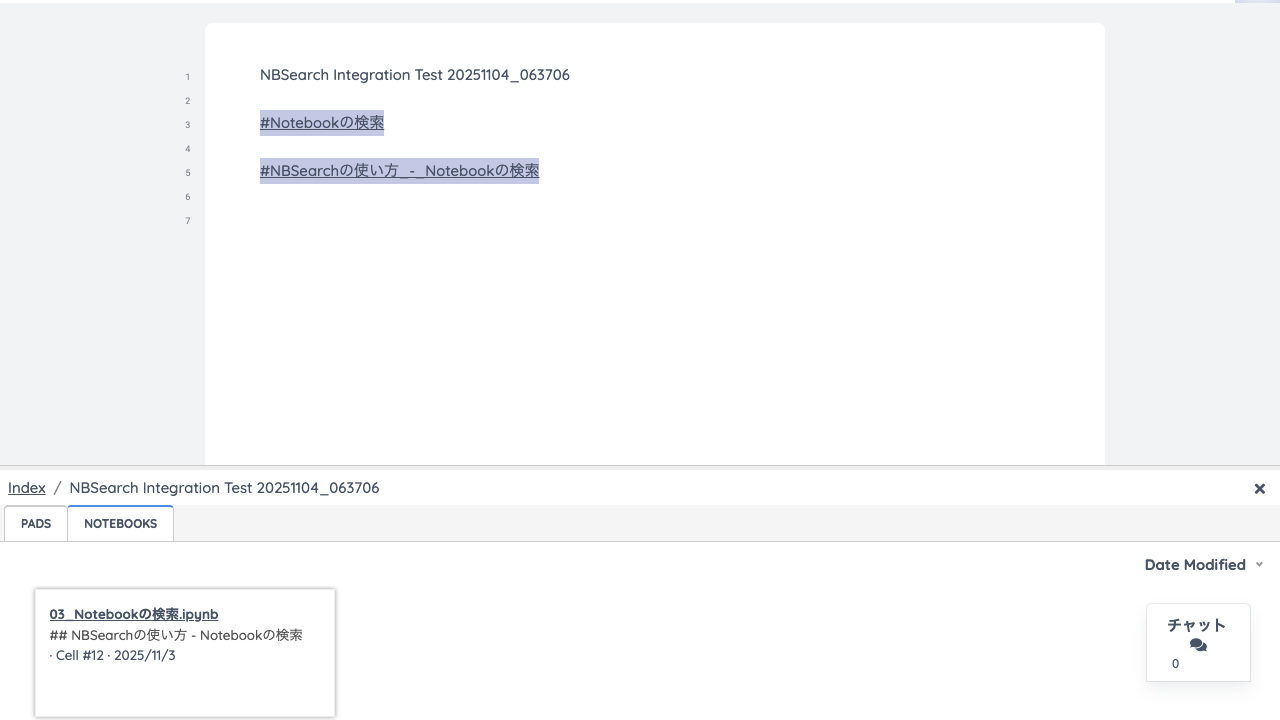

In [30]:
async def _step(page):
    # Ensure we're in the Notebooks tab (should still be there from previous steps)
    notebooks_content = page.locator('.hashview-tab-content[data-tab="notebooks"].hashview-tab-active')
    await expect(notebooks_content).to_be_visible(timeout=transition_timeout)
    
    # Find the section heading for the second hashtag
    section_heading_text = f"Notebooks with '{hashtag2}' in headings"
    section_heading = notebooks_content.locator('.hash-text', has_text=section_heading_text)
    await expect(section_heading).to_be_visible(timeout=transition_timeout)
    
    # Find notebook items for this hashtag
    # Expect exactly 1 result for the heading "NBSearchの使い方 - Notebookの検索"
    notebook_items = notebooks_content.locator(f'.hash-text:has-text("{section_heading_text}") + .hash-container .hash-link.notebook-item')
    await expect(notebook_items).to_have_count(1, timeout=transition_timeout)
    await notebook_items.scroll_into_view_if_needed()

await run_pw(_step)

Clean up

In [31]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpz0ss9yxq/video-1.webm
Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpz0ss9yxq/video-2.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpz0ss9yxq/har.zip


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/ep_weave/tests/e2e/notebooks/scripts/playwright.py", line 202, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpbj_gc6gx/videos/3c34e2d7427b9f2277235322397f03df.webm'
スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/ep_weave/tests/e2e/notebooks/scripts/playwright.py", line 202, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/va

In [32]:
!rm -fr {work_dir}